# P2: Compresión del Modelo (Pruning, QAT y Distillation)
*(Clasificación Binaria: Normal vs. Anómalo)*

<table style="width:100%;">
<tr>
<td width="70%">

**PyCon Colombia 2026 🇨🇴 - Workshop | hls4ml: From Python Models to Hardware Acceleration**  
*Versión para Google Colab*

</td>

<td width="30%" align="center" valign="middle">

<img src="../imgs/pycon_logo.png" width="100">
&nbsp;&nbsp;&nbsp;
<img src="../imgs/gicm_logo.png" width="100">

</td>
</tr>
</table>

El objetivo de este *notebook* es tomar el modelo **Teacher** que entrenamos en la etapa anterior (P1) y comprimirlo para que cumpla con las estrictas restricciones para la implementación en Hardware.

Para lograrlo, aplicaremos un flujo de optimización en dos fases:
1. **Pruning (Poda) + QAT (Quantization-Aware Training):** Eliminaremos las conexiones redundantes de la red y reduciremos la precisión numérica de sus parámetros durante el entrenamiento.

2. **Knowledge Distillation (Destilación):** Transferiremos el "conocimiento" de esta red optimizada a una nueva arquitectura **Student**, la cual será mucho más pequeña y estará lista para síntesis de hardware.



> ⚠️ **Nota sobre la ejecución en Google Colab:**  
> Debido a que esta máquina virtual no comparte archivos con el *notebook* P1, necesitas asegurar dos cosas antes de iniciar:
> * **1. Los Datos (Automático):** La primera celda de este script regenerará el dataset PTB (187 puntos) para que no tengas que subirlo.
> * **2. El Modelo Teacher (Manual):** Deberás **subir manualmente** el archivo `teacher_model.h5` (que descargaste al final de P1) arrastrándolo hacia el panel de archivos a la izquierda de tu pantalla, guardandolo en la carpeta `./hls4ml_workshop/models/`

In [ ]:
# ============================================================
# Setup P2: Preparación del entorno
# ============================================================

# 1. Instalar las dependencias necesarias
!pip install -q tensorflow==2.12.0 keras==2.12.0 qkeras==0.9.0 tensorflow-model-optimization==0.8.0


print("Entorno preparado correctamente.")
print("Directorio actual del kernel:")
print(os.getcwd())

In [ ]:
import os
from IPython.display import clear_output
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

print("Preparando el entorno...")
# 2. Clonar el repositorio
if not os.path.exists("hls4ml_workshop"):
    !git clone -q https://github.com/GICM-UdeA/hls4ml_workshop.git

# 3. Acceder al directorio del proyecto
os.chdir("hls4ml_workshop")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.7 MB/s eta 0:00:00


In [ ]:
# 4. Forzamos el reinicio del entorno de ejecución
os.kill(os.getpid(), 9)

In [ ]:
# 5. Verificamos las versiones de Tensorflow y Keras
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

**Preparación de datos** (Versión condensada de *P0_Dataset_PTB.ipynb*)

In [ ]:
# ============================================================
# Preparación de datos
# ============================================================

print("Cargando y procesando el dataset...")

data_dir = Path('./dataset')
LABEL_COL = 187

# 1. Carga de datos crudos
raw_normal   = pd.read_csv(data_dir / 'ptbdb_normal.csv', header=None)
raw_abnormal = pd.read_csv(data_dir / 'ptbdb_abnormal.csv', header=None)

# 2. Extracción de características y asignación de etiquetas
normal_vect   = raw_normal.iloc[:, :LABEL_COL].values.astype(np.float32)
abnormal_vect = raw_abnormal.iloc[:, :LABEL_COL].values.astype(np.float32)

df_normal_full = pd.DataFrame(normal_vect)
df_normal_full['class'] = 0

df_abnormal_full = pd.DataFrame(abnormal_vect)
df_abnormal_full['class'] = 1

# 3. Partición balanceada para Prueba (Test)
n_samples = min(1000, len(df_normal_full), len(df_abnormal_full))

test_normal   = df_normal_full.sample(n=n_samples, random_state=45)
test_abnormal = df_abnormal_full.sample(n=n_samples, random_state=45)

train_normal   = df_normal_full.drop(test_normal.index)
train_abnormal = df_abnormal_full.drop(test_abnormal.index)

# 4. Concatenación y mezcla aleatoria (Shuffle)
test_df  = pd.concat([test_normal, test_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)
train_df = pd.concat([train_normal, train_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Exportación
test_df.to_csv(data_dir / "test_dataset.csv", index=False)
train_df.to_csv(data_dir / "train_dataset.csv", index=False)

print("Dataset preparado y exportado correctamente:")
print(f"   - Entrenamiento : {train_df.shape[0]} muestras {train_df.shape}")
print(f"   - Prueba (Test) : {test_df.shape[0]} muestras {test_df.shape}")

Cargando y procesando el dataset...
Dataset preparado y exportado correctamente:
   - Entrenamiento : 12552 muestras (12552, 188)
   - Prueba (Test) : 2000 muestras (2000, 188)


**Librerías de entrenamiento y optimización (pipeline ML)**

**Importante:** `src.distillationClassKeras` contiene la clase `Distiller` que se usa más abajo para Knowledge Distillation. esta se llama desde el directorio `./src` dentro del repositorio clonado del proyecto `hls4ml_workshop`

In [16]:
from numpy import array

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2, l1

import tensorflow_model_optimization as tfmot

# Pruning API
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_schedule, pruning_callbacks
from tensorflow_model_optimization.sparsity.keras import strip_pruning

# Quantization API
from qkeras import *

# Knowledge Distillation (requiere src/distillationClassKeras.py)
from src.distillationClassKeras import *

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Pre-processing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Training utils
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

N_INPUT = 187   # EJ-299-33 usaba 161

**Inicialización de la Función de preprocesamiento** `preproc_dataset()`

Misma adaptación que en *P1_TF_Training_ECG.ipynb*: sin normalización `/512.0` (PTB ya viene en [0,1]).

In [17]:
def preproc_dataset(signal_dfAbnormal, signal_dfNormal,
                    train_size=2000,
                    test_size=500,
                    seed=42):

    LABEL = "class"

    signal_dfAbnormal = shuffle(signal_dfAbnormal, random_state=seed)
    signal_dfNormal   = shuffle(signal_dfNormal,   random_state=seed)

    max_available = min(len(signal_dfAbnormal), len(signal_dfNormal)) - test_size
    if train_size > max_available:
        print(f"Ajustando train_size de {train_size} a {max_available} (maximo disponible)")
        train_size = max_available

    train_abnormal = signal_dfAbnormal.iloc[:train_size]
    test_abnormal  = signal_dfAbnormal.iloc[train_size:train_size+test_size]

    train_normal = signal_dfNormal.iloc[:train_size]
    test_normal  = signal_dfNormal.iloc[train_size:train_size+test_size]

    dfTrain = pd.concat([train_abnormal, train_normal])
    dfTest  = pd.concat([test_abnormal,  test_normal])

    dfTrain = shuffle(dfTrain, random_state=seed).reset_index(drop=True)
    dfTest  = shuffle(dfTest,  random_state=seed).reset_index(drop=True)

    # PTB ya viene en [0,1] -> no se re-normaliza aqui
    return dfTrain, dfTest

**Carga y preprocesamiento del Dataset**

In [20]:
PATH = "dataset/"
TRAIN_DATASET_FILE = PATH + "train_dataset.csv"
TEST_DATASET_FILE  = PATH + "test_dataset.csv"

dfTrain = pd.read_csv(TRAIN_DATASET_FILE)
dfTestPTB = pd.read_csv(TEST_DATASET_FILE)

dfNormal   = dfTrain[dfTrain["class"] == 0]
dfAbnormal = dfTrain[dfTrain["class"] == 1]

In [21]:
df_train, dfTest = preproc_dataset(dfAbnormal, dfNormal)

df_train_ = df_train.pop('class')
dfTest_   = dfTest.pop('class')

le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(y, 2)

le = LabelEncoder()
yTest = le.fit_transform(dfTest_)
yTest = to_categorical(yTest, 2)

x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.3, random_state=42)

x_train = x_train.astype(np.float32)
x_val   = x_val.astype(np.float32)

print(f"x_train: {x_train.shape} | x_val: {x_val.shape} | dfTest: {dfTest.shape}")

x_train: (2800, 187) | x_val: (1200, 187) | dfTest: (1000, 187)


---

## 1.) Carga del modelo Teacher

**IMPORTANTE**

**Antes de Ejecutar la Celda:** Dada la no persistencia del entorno de Google Colab, sube el archivo `teacherModel_ECG_PTB.h5` que descargaste al final de notebook *P1_TF_Training_ECG.ipynb* hacia el directorio `./models/` dentro del repositorio clonado.

In [24]:
teacher_path = Path('./models/teacherModel_ECG_PTB.h5')
teacher_path.parent.mkdir(exist_ok=True)

teacher_model = keras.models.load_model(str(teacher_path))
teacher_model.summary()

Model: "teacher_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 10)                1880      
                                                                 
 relu1 (Activation)          (None, 10)                0         
                                                                 
 fc2 (Dense)                 (None, 5)                 55        
                                                                 
 relu2 (Activation)          (None, 5)                 0         
                                                                 
 fc3 (Dense)                 (None, 7)                 42        
                                                                 
 relu3 (Activation)          (None, 7)                 0         
                                                                 
 dropout (Dropout)           (None, 7)                 

---

## 2.) Configuración de la Poda (Pruning)

Antes de comprimir el modelo, necesitamos definir los hiperparámetros. Configuraremos tres elementos clave:

1. **Hiperparámetros estándar:** Tasa de aprendizaje, épocas y tamaño de lote.

2. **Pruning Schedule:** Usaremos un decaimiento polinomial. La red empezará con 0% de *sparsity* (conexiones eliminadas) y llegará gradualmente a un **30%** en los primeros 1,000 pasos de entrenamiento.

3. **Callbacks:** Un reductor automático del *Learning Rate* si el modelo se estanca, y el actualizador obligatorio de *Pruning* de TensorFlow.

In [25]:
# Hiperparámetros de entrenamiento
epochs = 100
lr = 0.001
loss = 'categorical_crossentropy'
op = Adam(learning_rate=lr)
metrics = ['accuracy']
batch = 64
val_split = 0.2

# Configuración de la poda (Pruning)
final_sparsity = 0.3

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=1000
    )
}

In [26]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=3,
        verbose=1
    ),
    pruning_callbacks.UpdatePruningStep()
]

### 2.1.) Aplicación de Pruning y Reentrenamiento (Fine-tuning)

Aplicamos la API de *Pruning* de TensorFlow. 

**¿Por qué necesitamos entrenar de nuevo?**
Al eliminar (podar) conexiones de la red neuronal, el modelo sufre un daño estructural y pierde precisión. Por ello, debemos realizar un *Fine-tuning* (reentrenamiento): la red aprenderá a compensar las conexiones perdidas utilizando las conexiones que aún le quedan.

In [27]:
# Aplicar la poda al modelo Teacher
modelP = tfmot.sparsity.keras.prune_low_magnitude(
    teacher_model,
    **pruning_params
)

# Compilar el modelo podado con la configuración de entrenamiento
modelP.compile(
    optimizer=op,
    loss=loss,
    metrics=metrics
)

In [28]:
# Entrenar el modelo con poda
history_P = modelP.fit(
    x=x_train,
    y=y_train,
    validation_split=val_split,
    batch_size=batch,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
35/35 [==============================] - 4s 9ms/step - loss: 0.4615 - accuracy: 0.8174 - val_loss: 0.4268 - val_accuracy: 0.8464 - lr: 0.0010
Epoch 2/100
35/35 [==============================] - 0s 2ms/step - loss: 0.4316 - accuracy: 0.8366 - val_loss: 0.4285 - val_accuracy: 0.8393 - lr: 0.0010
Epoch 3/100
35/35 [==============================] - 0s 2ms/step - loss: 0.4348 - accuracy: 0.8357 - val_loss: 0.4286 - val_accuracy: 0.8393 - lr: 0.0010
Epoch 4/100
 1/35 [..............................] - ETA: 0s - loss: 0.4623 - accuracy: 0.7969
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
35/35 [==============================] - 0s 2ms/step - loss: 0.4408 - accuracy: 0.8357 - val_loss: 0.4352 - val_accuracy: 0.8250 - lr: 0.0010
Epoch 5/100
35/35 [==============================] - 0s 2ms/step - loss: 0.4357 - accuracy: 0.8326 - val_loss: 0.4200 - val_accuracy: 0.8571 - lr: 4.0000e-04
Epoch 6/100
35/35 [==============================] - 0s 4ms/step - 

**Evaluación del Modelo Podado (Pruning)**

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


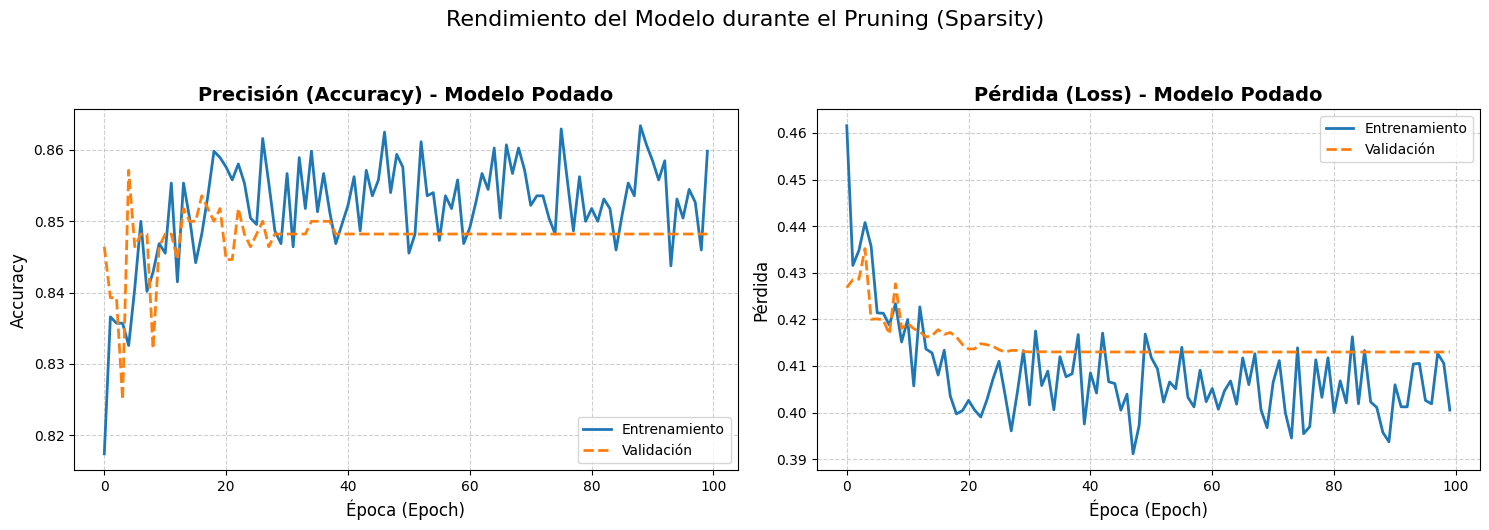

In [29]:
print(history_P.history.keys())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
axes[0].plot(history_P.history['accuracy'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[0].plot(history_P.history['val_accuracy'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[0].set_title('Precisión (Accuracy) - Modelo Podado', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Época (Epoch)', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfica 2: Pérdida (Loss) ---
axes[1].plot(history_P.history['loss'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[1].plot(history_P.history['val_loss'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[1].set_title('Pérdida (Loss) - Modelo Podado', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pérdida', fontsize=12)
axes[1].set_xlabel('Época (Epoch)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Rendimiento del Modelo durante el Pruning (Sparsity)', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

**Matriz de confusión generada posterior al podado**

32/32 [==============================] - 0s 811us/step


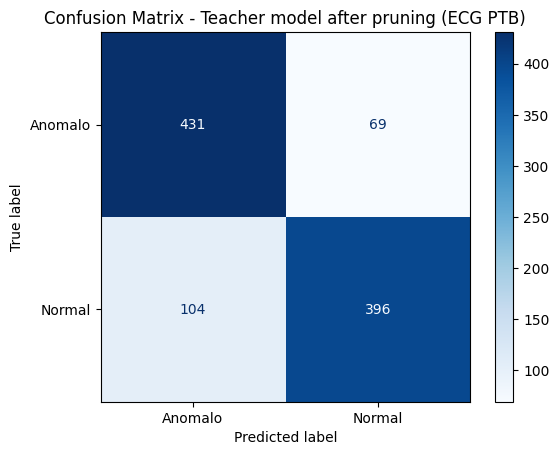

In [30]:
y_pred_probs = modelP.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(yTest, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomalo', 'Normal'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model after pruning (ECG PTB)')
plt.show()

### 2.2.) Remover los Wrappers de Pruning (Strip Pruning)

Durante el entrenamiento, TensorFlow añadió "envoltorios" (*wrappers*) a nuestras capas para simular la eliminación de las conexiones (multiplicándolas por máscaras de ceros). 

Sin embargo al hardware (FPGA) no le interesan esas operaciones de enmascaramiento; solo le interesan los pesos finales. Por ello, debemos aplicar la función `strip_pruning()`, la cual elimina la infraestructura de entrenamiento y nos devuelve un modelo de Keras estándar y limpio, donde los pesos podados son ahora ceros absolutos.

In [ ]:
modelP = strip_pruning(modelP)
modelP.summary()

Model: "teacher_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 10)                1880      
                                                                 
 relu1 (Activation)          (None, 10)                0         
                                                                 
 fc2 (Dense)                 (None, 5)                 55        
                                                                 
 relu2 (Activation)          (None, 5)                 0         
                                                                 
 fc3 (Dense)                 (None, 7)                 42        
                                                                 
 relu3 (Activation)          (None, 7)                 0         
                                                                 
 dropout (Dropout)           (None, 7)                 

---

## 3.) Cuantización (Quantization)

**Quantization-Aware Training (QAT)**

Para implementaciones en hardware reprogramable (como las FPGA), se deben considerar las limitaciones de área en el silicio y la velocidad de cómputo. Por lo tanto, operar con números de punto flotante estándar de 32 bits (FP32) resulta demasiado costoso en términos de recursos lógicos y de potencia.

Para lograr esto sin destruir el rendimiento del modelo, aplicaremos **QAT (Quantization-Aware Training)** usando la librería `QKeras`. Esto simulará la baja precisión matemática *durante* el entrenamiento, obligando a la red a adaptarse y mantener su exactitud a pesar de la restricción numérica.

> **(Cambio vs. código base EJ-299-33)**  
> Si estás adaptando código de proyectos anteriores de ECG, recuerda que el dataset PTB tiene **187 puntos por latido**, no 161. Asegúrate de que el `input_shape` en la definición de tu modelo sea `(187, 1)` o equivalente. Si mantienes la dimensión antigua, el modelo fallará al intentar recibir los datos.

### 3.1.) Construcción de la arquitectura QKeras de la red neuronal

Para ello, usamos la función `quantized_bits(8, 4, alpha=1)`:
* **8**: Número total de bits.
* **4**: Bits asignados a la parte entera (dejando los restantes para los decimales y el signo).
* **alpha=1**: Mantiene la escala de los pesos original, ideal para la convergencia inicial.



In [33]:
## Estrategia de cuantizacion: 8 bits para kernel, bias y activacion

neurons_teacher = [10, 5, 7, 5, 6]

kernelQ      = "quantized_bits(8,4,alpha=1)"
biasQ        = "quantized_bits(8,4,alpha=1)"
activationQ  = "quantized_bits(8,4,alpha=1)"

modelQAT = Sequential(
    [
        QDense(neurons_teacher[0], name='input', input_shape=(N_INPUT,),
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu0'),

                    QDense(neurons_teacher[1], name='fc1',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu1'),

                    QDense(neurons_teacher[2], name='fc2',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu2'),
                    Dropout(0.1),

                    QDense(neurons_teacher[3], name='fc3',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu3'),
                    Dropout(0.2),

                    QDense(neurons_teacher[4], name='fc4',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu4'),
                    Dropout(0.2),

                    QDense(2, name='output',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    Activation(activation='sigmoid', name='sigmoid')
    ],
    name = "QuantizedModel",
)

In [34]:
modelQAT.summary()

Model: "QuantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (QDense)              (None, 10)                1880      
                                                                 
 relu0 (QActivation)         (None, 10)                0         
                                                                 
 fc1 (QDense)                (None, 5)                 55        
                                                                 
 relu1 (QActivation)         (None, 5)                 0         
                                                                 
 fc2 (QDense)                (None, 7)                 42        
                                                                 
 relu2 (QActivation)         (None, 7)                 0         
                                                                 
 dropout (Dropout)           (None, 7)              

### 3.2.) Entrenamiento de modelo cuantizado `modelQAT`

In [35]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=3,
        verbose=1
    ),
    pruning_callbacks.UpdatePruningStep()
]

In [36]:
epochs = 150
lr = 0.0001
loss = 'binary_crossentropy'
op = Adam(learning_rate=lr)
metrics = ['accuracy']
batch = 32
val_split = 0.2

modelQAT.compile(optimizer=op, loss=loss, metrics=metrics)

history_QAT = modelQAT.fit(x=x_train, y=y_train,
                       validation_split=val_split,
                       epochs=epochs,
                       batch_size=batch,
                       callbacks=callbacks,
                       verbose=1
                       )

Epoch 1/150
70/70 [==============================] - 2s 7ms/step - loss: 0.6912 - accuracy: 0.5522 - val_loss: 0.6784 - val_accuracy: 0.5804 - lr: 1.0000e-04
Epoch 2/150
70/70 [==============================] - 0s 1ms/step - loss: 0.6823 - accuracy: 0.5728 - val_loss: 0.6697 - val_accuracy: 0.6071 - lr: 1.0000e-04
Epoch 3/150
70/70 [==============================] - 0s 1ms/step - loss: 0.6711 - accuracy: 0.5987 - val_loss: 0.6650 - val_accuracy: 0.6304 - lr: 1.0000e-04
Epoch 4/150
70/70 [==============================] - 0s 1ms/step - loss: 0.6651 - accuracy: 0.6147 - val_loss: 0.6514 - val_accuracy: 0.6643 - lr: 1.0000e-04
Epoch 5/150
70/70 [==============================] - 0s 1ms/step - loss: 0.6473 - accuracy: 0.6728 - val_loss: 0.6344 - val_accuracy: 0.7036 - lr: 1.0000e-04
Epoch 6/150
70/70 [==============================] - 0s 2ms/step - loss: 0.6400 - accuracy: 0.6754 - val_loss: 0.6231 - val_accuracy: 0.7036 - lr: 1.0000e-04
Epoch 7/150
70/70 [==============================] -

**Validación del modelo cuantizado**

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


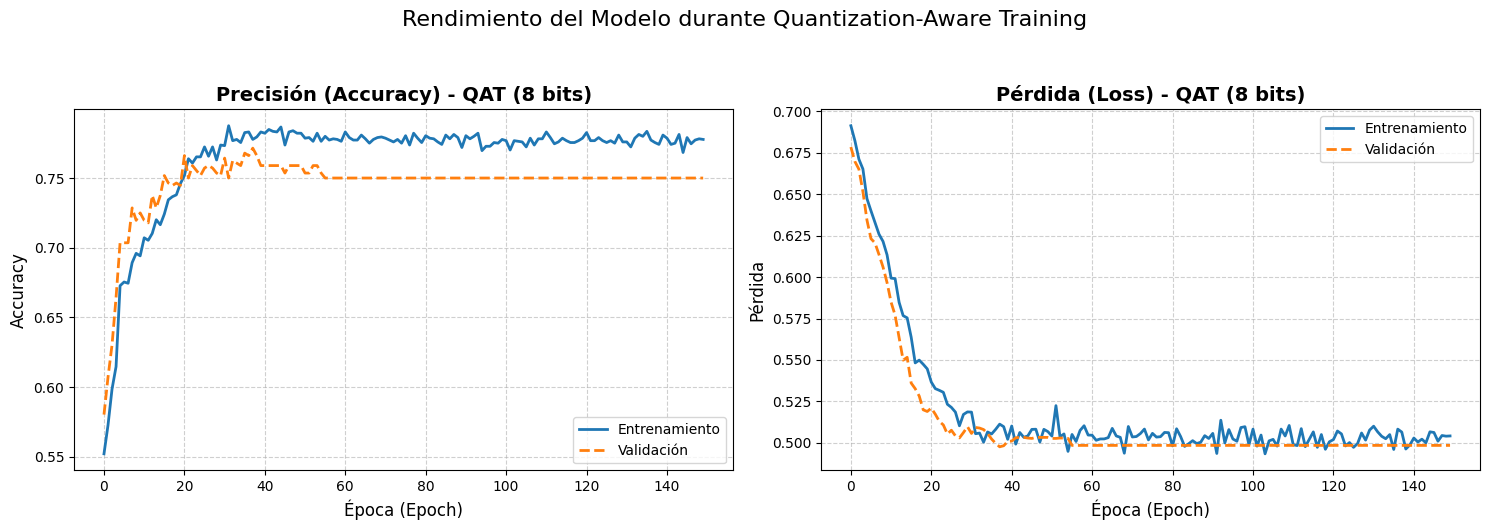

In [37]:
print(history_QAT.history.keys())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
axes[0].plot(history_QAT.history['accuracy'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[0].plot(history_QAT.history['val_accuracy'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[0].set_title('Precisión (Accuracy) - QAT (8 bits)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Época (Epoch)', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfica 2: Pérdida (Loss) ---
axes[1].plot(history_QAT.history['loss'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[1].plot(history_QAT.history['val_loss'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[1].set_title('Pérdida (Loss) - QAT (8 bits)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pérdida', fontsize=12)
axes[1].set_xlabel('Época (Epoch)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Rendimiento del Modelo durante Quantization-Aware Training', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

**Matriz de Confusión**

32/32 [==============================] - 0s 600us/step


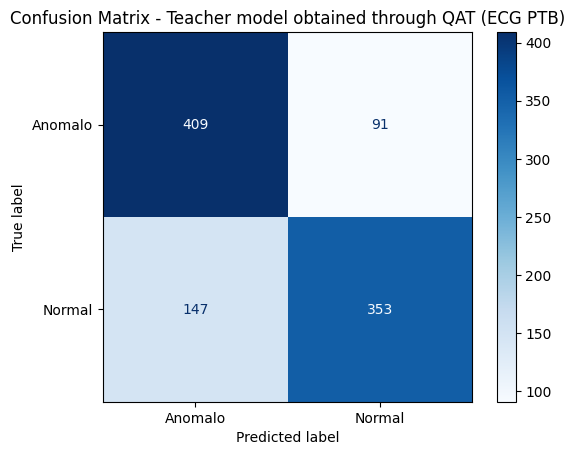

In [38]:
y_pred_probs = modelQAT.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(yTest, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomalo', 'Normal'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model obtained through QAT (ECG PTB)')
plt.show()

**Guardado del modelo podado y cuantizado**

In [39]:
modelQAT.save('models/teacherQATModel_ECG_PTB.h5')

---

## 4. Knowledge Distillation: Entrenando al "Estudiante"

Para obtener un modelo lo suficientemente pequeño y rápido para ser implementado en una FPGA, utilizaremos **Knowledge Distillation (Destilación de Conocimiento)**. 

En lugar de entrenar una red pequeña desde cero con las etiquetas originales (1 o 0), usaremos nuestro modelo maestro (`modelQAT`) para que le "enseñe" a un modelo **Student** (estudiante). El modelo estudiante aprenderá de las probabilidades continuas (soft labels) que escupe el maestro, capturando así los matices y la "intuición" de la red más grande.

Para garantizar que el *Student* pueda ser contenido en el hardware le aplicaremos restricciones:

- **Cuantización heterogénea:** Usaremos entre 4 y 8 bits dependiendo de la sensibilidad de cada capa.

- **Poda severa (Sparsity):** Alcanzaremos un **50%** de conexiones eliminadas.

---

### Referencias

Esta estrategia de cuantización heterogénea está basada en el trabajo de

- *Coelho et al. (2020). "Ultra low-latency, low-area inference accelerators using heterogeneous deep quantization with QKeras and hls4ml"*. [arXiv:2006.10159](https://arxiv.org/abs/2006.10159).

### 4.1.) Hiperparámetros para el modelo Student

**Cambio vs. EJ-299-33:** `Input(shape=(161,))` → `Input(shape=(N_INPUT,))` (187). El resto de la arquitectura de cuantización es idéntica.

In [40]:
lr = 0.001
neurons_student = [6, 4, 2, 4, 3]

In [41]:
def student_topology(neurons_student):
    kernelQ_4b = "quantized_bits(4,2,alpha=1)"
    biasQ_4b = "quantized_bits(4,2,alpha=1)"
    activationQ_4b = 'quantized_bits(4, 0)'

    kernelQ = "quantized_bits(8,4,alpha=1)"
    biasQ = "quantized_bits(8,4,alpha=1)"
    activationQ = 'quantized_bits(8,4)'

    kernelQ_16b = "quantized_bits(16,6,alpha=1)"
    biasQ_16b = "quantized_bits(16,6,alpha=1)"
    activationQ_16b = 'quantized_bits(16,6)'

    studentQ_MLP = keras.Sequential(
            [
                Input(shape=(N_INPUT,), name='inputLayer'),
                QDense(neurons_student[0], name='fc1',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu0'),
                Dropout(0.1),

                QDense(neurons_student[1], name='fc2',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu1'),
                Dropout(0.1),

                QDense(neurons_student[2], name='fc3',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu2'),
                Dropout(0.1),

                QDense(neurons_student[3], name='fc4',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu3'),
                Dropout(0.2),

                QDense(neurons_student[4], name='fc5',
                       kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                       kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu4'),
                Dropout(0.2),

                QDense(2, name='output',
                        kernel_quantizer=kernelQ_16b, bias_quantizer=biasQ_16b,
                        kernel_initializer='lecun_uniform'),
                Activation(activation='sigmoid', name='outputActivation')
            ],
            name="studentMLP",
        )

    return studentQ_MLP

### 4.2.) Construcción y entrenamiento del modelo estudiante

Para crear a nuestro estudiante, combinaremos ambas técnicas simultáneamente. 
Esta función recibe la topología base del estudiante y la envuelve con la API de poda de TensorFlow. 

**¿Cómo sabe la red cuándo terminar de podar?**
La herramienta de *Pruning* de TensorFlow no mide el tiempo en "épocas", sino en **pasos** (cada vez que procesa un pequeño bloque o *batch* de datos). 

Para que la poda sea gradual y perfecta, calculamos los pasos totales con un ejemplo simple:
* Si tenemos **1,000 datos** y los procesamos en lotes de **100**, la red da **10 pasos** por época.
* Si entrenamos durante **20 épocas**, dará un total de **200 pasos**.

Nuestra fórmula calcula este número automáticamente. De esta forma, le decimos a la red: *"Ve cortando conexiones poco a poco, hasta llegar exactamente al 50% de compresión en el último paso del entrenamiento"*.

In [42]:
def build_student(student_neurons, x_train, batch_size=64, epochs=200):
    qmodel = student_topology(student_neurons)

    steps_per_epoch = np.ceil(len(x_train) / batch_size)
    end_step = steps_per_epoch * epochs

    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=0.5,
            begin_step=0,
            end_step=end_step
        )
    }

    studentQ = tfmot.sparsity.keras.prune_low_magnitude(
        qmodel,
        **pruning_params
    )

    return studentQ

### 4.3.) Compilación del modelo Student para KD y QAT

In [43]:
studentQ = build_student(neurons_student, x_train)
studentQ.summary()

Model: "studentMLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_fc1 (Pr  (None, 6)                2252      
 uneLowMagnitude)                                                
                                                                 
 prune_low_magnitude_relu0 (  (None, 6)                1         
 PruneLowMagnitude)                                              
                                                                 
 prune_low_magnitude_dropout  (None, 6)                1         
 _3 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_fc2 (Pr  (None, 4)                54        
 uneLowMagnitude)                                                
                                                                 
 prune_low_magnitude_relu1 (  (None, 4)                1

### 4.4.) Destilación de Conocimiento (KD)

Para transferir el conocimiento del modelo *Teacher* (Maestro) al modelo *Student* (Estudiante), utilizaremos una clase personalizada llamada `Distiller`. 

En lugar de que el estudiante aprenda solo de las etiquetas originales (las respuestas correctas), aprenderá también de las **predicciones suaves** del maestro. Para controlar este proceso, configuramos dos hiperparámetros clave:

* **Temperatura (`temperature=10`):** Normalmente, una red neuronal arroja predicciones muy extremas (ej. 99% de seguridad de que es un latido normal, 1% anormal). Al aumentar la temperatura, "suavizamos" estas probabilidades (ej. 80% vs 20%). Esto le revela al estudiante la "intuición" oculta del maestro, mostrándole qué clases se parecen entre sí.

* **Alfa (`alpha=0.1`):** Controla a quién le hace más caso el estudiante. Un `alpha` de 0.1 significa que el estudiante le dará un **10% de importancia a la etiqueta real** y un **90% de importancia a imitar al maestro** (calculado como `1 - alpha`).


> **Detalle Técnico:** 
> Como usaremos la pérdida `SparseCategoricalCrossentropy`, necesitamos convertir nuestras etiquetas `y_train` (que están en formato *one-hot* como `[1, 0]`) a números enteros simples (`0` o `1`). Para eso usamos `np.argmax`.

In [45]:
# 1. Instanciar la clase destiladora con ambos modelos
distilled_student = Distiller(student=studentQ, teacher=modelQAT)
# 2. Compilar con las funciones de pérdida para el estudiante y la destilación
adam = Adam(learning_rate=lr)

# 3. Convertir etiquetas (De One-Hot [1, 0] a Índices Enteros [0])
train_labels = np.argmax(y_train, axis=1)

distilled_student.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],

        # Pérdida 1: Cómo aprende el estudiante de la etiqueta real (Loss Estándar)
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),

        # Pérdida 2: Cómo el estudiante imita al maestro (Divergencia KL)
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1,      # 10% de peso a la etiqueta real, 90% a imitar al maestro
        temperature=10, # Suavizado matemático de las probabilidades
    )

### 4.5.) Entrenamiento del modelo Student

In [46]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_student_loss',
        factor=0.3,
        patience=3,
        verbose=1
    ),
    pruning_callbacks.UpdatePruningStep(),
]

history_student = distilled_student.fit(
    x=x_train,
    y=train_labels,
    batch_size=64,
    epochs=200,
    validation_split=0.2,
    callbacks=callbacks,
)

Epoch 1/200


c:\Users\fisica\Desktop\JLG\ML4HLS_Tutorial_base\.env\lib\site-packages\keras\backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


35/35 [==============================] - 5s 15ms/step - sparse_categorical_accuracy: 0.5281 - student_loss: 0.6980 - distillation_loss: 4.0817e-04 - val_sparse_categorical_accuracy: 0.6071 - val_student_loss: 0.6826 - lr: 0.0010
Epoch 2/200
 1/35 [..............................] - ETA: 0s - sparse_categorical_accuracy: 0.4844 - student_loss: 0.6716 - distillation_loss: 3.5650e-04

c:\Users\fisica\Desktop\JLG\ML4HLS_Tutorial_base\.env\lib\site-packages\keras\backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


35/35 [==============================] - 0s 3ms/step - sparse_categorical_accuracy: 0.5536 - student_loss: 0.6781 - distillation_loss: 3.7889e-04 - val_sparse_categorical_accuracy: 0.7000 - val_student_loss: 0.6484 - lr: 0.0010
Epoch 3/200
35/35 [==============================] - 0s 3ms/step - sparse_categorical_accuracy: 0.6250 - student_loss: 0.6474 - distillation_loss: 3.4320e-04 - val_sparse_categorical_accuracy: 0.7304 - val_student_loss: 0.6042 - lr: 0.0010
Epoch 4/200
35/35 [==============================] - 0s 3ms/step - sparse_categorical_accuracy: 0.6554 - student_loss: 0.6138 - distillation_loss: 2.9569e-04 - val_sparse_categorical_accuracy: 0.7429 - val_student_loss: 0.5915 - lr: 0.0010
Epoch 5/200
35/35 [==============================] - 0s 2ms/step - sparse_categorical_accuracy: 0.6915 - student_loss: 0.5856 - distillation_loss: 2.5877e-04 - val_sparse_categorical_accuracy: 0.7643 - val_student_loss: 0.5782 - lr: 0.0010
Epoch 6/200
35/35 [==============================] -

**Evaluación del modelo estudiante (QAT+KD)**

dict_keys(['sparse_categorical_accuracy', 'student_loss', 'distillation_loss', 'val_sparse_categorical_accuracy', 'val_student_loss', 'lr'])


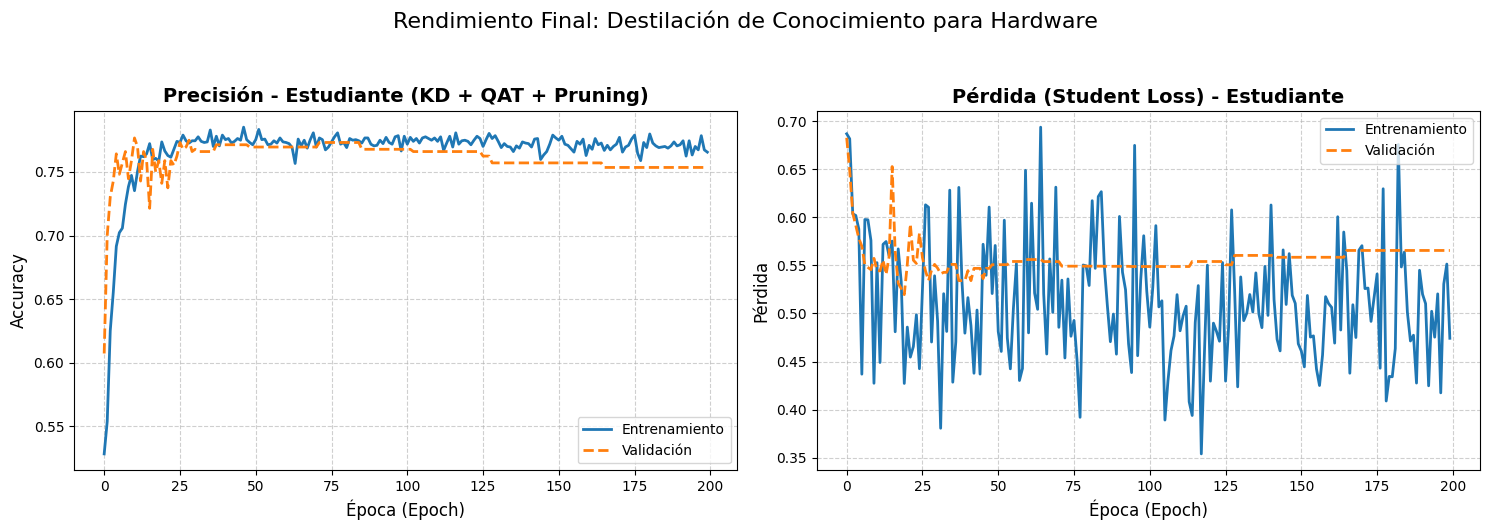

In [48]:
print(history_student.history.keys())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- Gráfica 1: Precisión (Sparse Categorical Accuracy) ---
axes[0].plot(history_student.history['sparse_categorical_accuracy'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[0].plot(history_student.history['val_sparse_categorical_accuracy'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[0].set_title('Precisión - Estudiante (KD + QAT + Pruning)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Época (Epoch)', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfica 2: Pérdida (Student Loss) ---
axes[1].plot(history_student.history['student_loss'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[1].plot(history_student.history['val_student_loss'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[1].set_title('Pérdida (Student Loss) - Estudiante', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pérdida', fontsize=12)
axes[1].set_xlabel('Época (Epoch)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Rendimiento Final: Destilación de Conocimiento para Hardware', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

**Matriz de Confusión**

32/32 [==============================] - 0s 915us/step


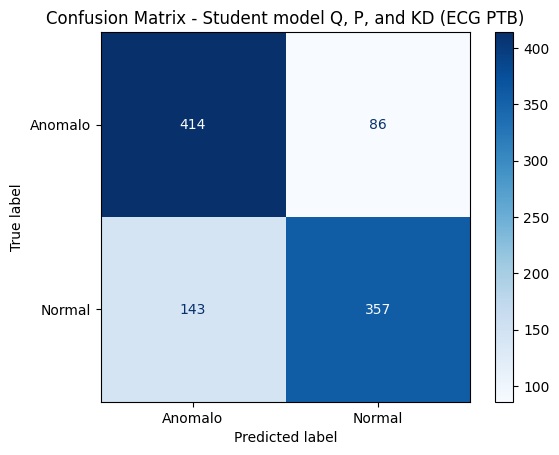

In [49]:
y_pred_probs = distilled_student.student.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(yTest, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomalo', 'Normal'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Student model Q, P, and KD (ECG PTB)')
plt.show()

### 4.6. Prueba de Predicción Individual (Inferencia)

Las métricas generales son útiles, pero aquí tomaremos un latido cardíaco individual de nuestro conjunto de pruebas y simularemos cómo lo procesaría el hardware.

> **Detalle clave de Hardware:**  
> Nota que para hacer la inferencia llamamos a `distilled_student.student.predict()`. La clase `Distiller` y el modelo *Teacher* fueron herramientas de entrenamiento que se quedan en nuestra computadora. La FPGA **solo** recibirá la arquitectura y los pesos de este atributo `.student`.

Puedes cambiar el valor de `index_prediction` (entre 0 y 999) para probar diferentes señales del dataset.

In [79]:

def validate_ECG(index, model_dicts, df_x, y_true):
    """
    Evalúa una señal de ECG usando múltiples modelos, imprimiendo 
    sus probabilidades crudas y comparando las predicciones.
    """
    # 1. Extraer datos de la señal
    x_input = df_x.iloc[index]
    y_label_real = y_true[index]
    
    if isinstance(y_label_real, (list, np.ndarray)) and len(y_label_real) > 1:
        y_label_real = np.argmax(y_label_real)

    # Input Tensor
    input_pred = np.array(x_input).reshape(1, -1)

    print(f"\n[Señal Nº {index}] -> Clase Real: {y_label_real}")
    print("=" * 65)
    
    graph_text = []
    
    for nombre, modelo in model_dicts.items():
        # Obtener la salida cruda del modelo
        y_pred_probs = modelo.predict(input_pred, verbose=0)[0]
        
        # Soportar tanto si la salida es de 1 neurona (sigmoid) como de 2 (softmax)
        if len(y_pred_probs) == 1:
            prob_clase_1 = float(y_pred_probs[0])
            prob_clase_0 = 1.0 - prob_clase_1
            y_pred_probs_full = np.array([prob_clase_0, prob_clase_1])
        else:
            y_pred_probs_full = y_pred_probs
            
        prediccion = np.argmax(y_pred_probs_full)
        confianza = y_pred_probs_full[prediccion] * 100
        
        
        # Imprimir en consola los valores crudos formateados
        print(f"{nombre:16} | Pred: {prediccion} | Confianza: {confianza:5.1f}%")
        print(f"   └─ Valores crudos: {np.round(y_pred_probs_full, 4)}")
        
        # Guardar resumen para el título de la gráfica
        graph_text.append(f"{nombre}: Pred={prediccion} ({confianza:.1f}%)")

    # 2. Visualización de la señal
    plt.figure(figsize=(12, 4))
    plt.plot(x_input.values, color='#1f77b4', linewidth=1.5)

    titulo_preds = "\n".join(graph_text)
    plt.suptitle(f'Señal Nº {index} | Clase Real: {y_label_real} | Predicción:', fontsize=12)
    plt.title(titulo_preds, fontsize=10, color='dimgray')
              
    plt.xlabel('Muestras (Samples)', fontsize=10)
    plt.ylabel('Amplitud', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()


[Señal Nº 12] -> Clase Real: 0
Teacher Float    | Pred: 0 | Confianza:  83.9%
   └─ Valores crudos: [0.8388 0.1612]
Teacher QAT      | Pred: 0 | Confianza:  82.7%
   └─ Valores crudos: [0.8267 0.1689]
Estudiante (QAT+KD) | Pred: 0 | Confianza:  61.2%
   └─ Valores crudos: [0.6124 0.2406]


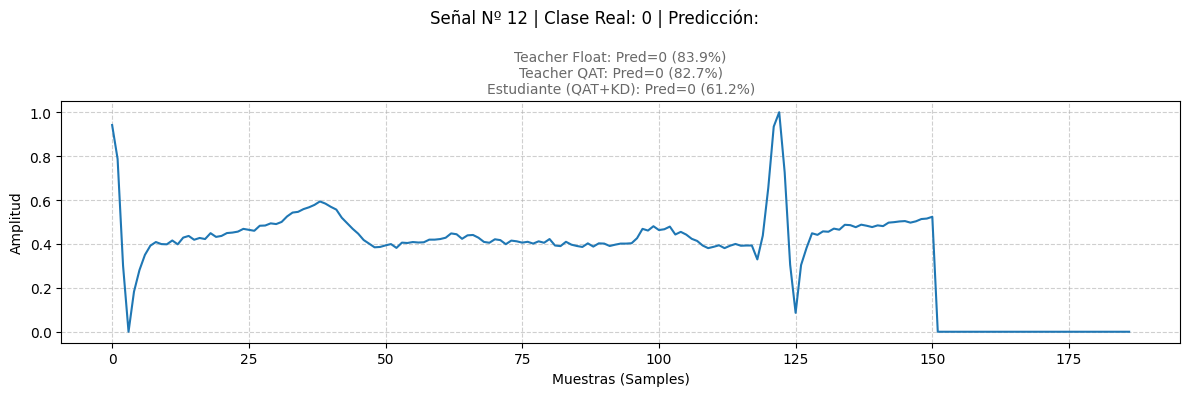


[Señal Nº 450] -> Clase Real: 0
Teacher Float    | Pred: 0 | Confianza:  94.9%
   └─ Valores crudos: [0.949 0.051]
Teacher QAT      | Pred: 0 | Confianza:  67.9%
   └─ Valores crudos: [0.6792 0.3775]
Estudiante (QAT+KD) | Pred: 0 | Confianza:  54.5%
   └─ Valores crudos: [0.5452 0.3786]


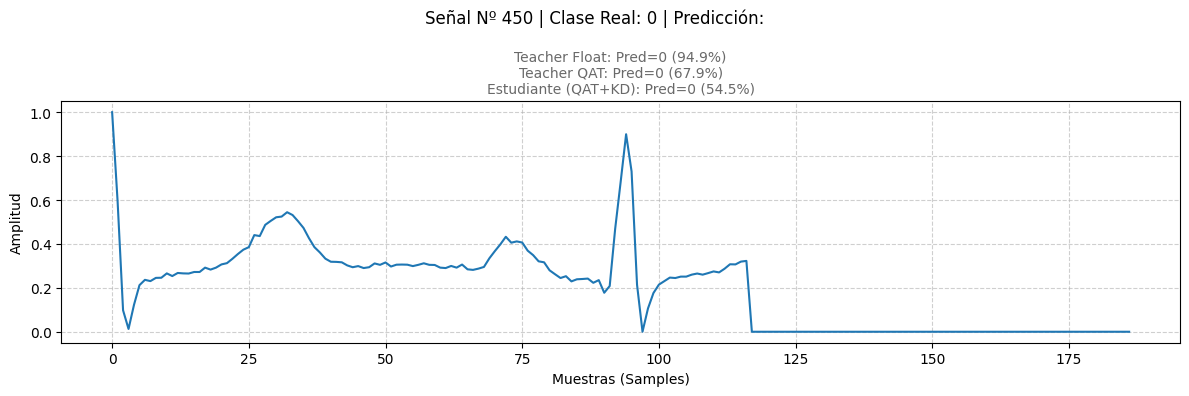

In [82]:
# ============================================================
# Ejecutar la prueba comparativa detallada
# ============================================================
models = {
    "Teacher Float": teacher_model,
    "Teacher QAT": modelQAT,
    "Estudiante (QAT+KD)": distilled_student.student
}

test_index = [12, 450]

for idx in test_index:
    validate_ECG(idx, models, dfTest, yTest)

### 4.7.) Guardar el modelo Student

In [ ]:
model_student = strip_pruning(distilled_student.student)
model_student.summary()

os.makedirs('models', exist_ok=True)
model_student.save('models/studentModel_ECG_PTB.h5')

from google.colab import files
files.download('models/studentModel_ECG_PTB.h5')

Model: "studentMLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 6)                 1128      
                                                                 
 relu0 (QActivation)         (None, 6)                 0         
                                                                 
 dropout_3 (Dropout)         (None, 6)                 0         
                                                                 
 fc2 (QDense)                (None, 4)                 28        
                                                                 
 relu1 (QActivation)         (None, 4)                 0         
                                                                 
 dropout_4 (Dropout)         (None, 4)                 0         
                                                                 
 fc3 (QDense)                (None, 2)                 1

---

**Siguiente paso:**

*P3_hls4ml_compilation.ipynb* Preparación y compilación del modelo mediante hls4ml para su síntesis en hardware con C++ orientado a Vitis HLS.


**Autores**: Natalia Echeverri, Jerónimo López, Fabian Castaño